In [1]:
# --- Verify Label Alignment in Training/Test Set (Animated Visualization) ---

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import pandas as pd

# Load preprocessed training data
data = np.load("Train_set_manual.npz")

# Or load preprocessed test data
# data = np.load("Test_set_manual.npz")

X = data["X"]
y = data["y"]
timestamps = data["timestamps"]

# Model and scaling parameters
n_layer = 4
factor = 2 ** n_layer

# Display dataset dimensions
print(len(X), X.shape[1])


3552 600


In [2]:
# Retrieve indices where the label equals 1 (i.e., event-active samples)
np.where(y == 1)[0]

array([   8,    8,    8, ..., 3551, 3551, 3551], dtype=int64)

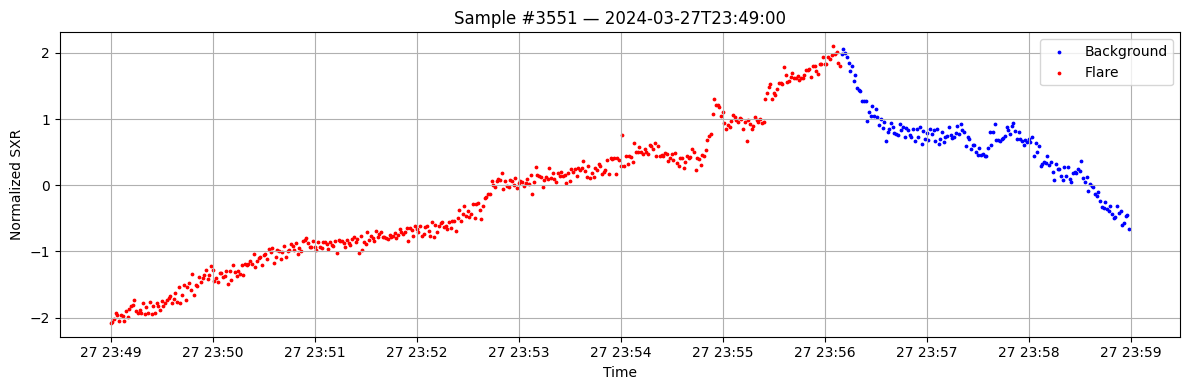

In [6]:
# --- Animated Visualization of Signal and Labels ---
sample_len = X.shape[1]

for i in range(3500, 3552):  # or any desired range
    x_sample = X[i]        # normalized signal
    y_sample = y[i]        # per-timestep labels
    t_window = timestamps[i]  # either a single timestamp or a list of timestamps

    # If timestamps[i] is a scalar (just the start time), construct full range
    if isinstance(t_window, (np.datetime64, pd.Timestamp)):
        sample_interval = 1  # seconds
        dt = pd.to_timedelta(sample_interval, unit='s')
        t_window = [t_window + j * dt for j in range(len(x_sample))]

    # Truncate if mismatched lengths
    min_len = min(len(x_sample), len(y_sample))
    x_sample = x_sample[:min_len]
    y_sample = y_sample[:min_len]
    t_window = t_window[:min_len]

    # Boolean masks
    flare_mask = y_sample == 1
    background_mask = y_sample == 0

    # Plot
    clear_output(wait=True)
    plt.figure(figsize=(12, 4))
    plt.scatter(np.array(t_window)[background_mask], x_sample[background_mask], s=3, color='blue', label='Background')
    plt.scatter(np.array(t_window)[flare_mask], x_sample[flare_mask], s=3, color='red', label='Flare')

    plt.title(f"Sample #{i} — {t_window[0].strftime('%Y-%m-%dT%H:%M:%S')}")
    plt.xlabel("Time")
    plt.ylabel("Normalized SXR")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # plt.savefig(f"frame_{i:04d}.png")
    plt.show()
    time.sleep(0.00005)
